In [1]:
import pandas as pd
import numpy as np
from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt


from matplotlib.ticker import MultipleLocator

font = {'family':'helvetica neue',
            'color':  'black',
            'weight': 'bold',
            'size': 12
            }
rs={'family':'helvetica neue',
    'size':14
   }

/Users/jesucastin/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
MTM_all=[1,2,3,4,5,6,7,8,9,10,12,36,37,38,39,40,41,42,43,44,46,80,82,84,85,112,114,115,116,117,118,119] 
MTM_core=[1, 2, 3, 4, 5, 6, 9, 10, 11, 12, 37, 38, 39, 40, 41, 42, 43, 45, 46, 119]
# MTM_vicinity=[i for i in MTM_all if i not in MTM_core]
# MTM_vicinity=[7,8,13,16,36,44,47,111,115,118]
MTM_vicinity=[7,8,44,]
# triad_res=[59,60,61,64,68]+[i for i in range(71,80)]+[i for i in range(83,93)]
# triad_neigh_res=[58,62,63,65,67,69,70,80,81,82,93,94]
triad_neigh_res=[62,65,69,80,81,82,93,94]
triad_res=[59,60,61,64,68]+[i for i in range(71,80)]+[i for i in range(83,93)]+triad_neigh_res

Triad_H3=[59,60,61,64,68]
Triad_L5=[i for i in range(71,80)]
Triad_L6=[i for i in range(83,93)]
hp_1=[19,23,32,34,51,53,108]
hp_2=[35,52,54,55,58,63,66,67,70]
pock=hp_1+hp_2

others=[i for i in range(1,120) if i not in MTM_all+triad_res+pock+triad_neigh_res+MTM_vicinity]

In [3]:
#PRE

WT_PRE_NC=pd.read_csv('../../../data/dihedrals/net_communication/preLC3B_OPLS/NET_COMM/preLC3B_OPLS_net_comm.csv',
                    index_col=0)
WT_PRE_full_np=WT_PRE_NC.to_numpy()+WT_PRE_NC.transpose().to_numpy()
WT_PRE_full_np=WT_PRE_full_np/np.max(WT_PRE_full_np)
WT_PRE_full_df=pd.DataFrame(WT_PRE_full_np)
WT_PRE_full_df

,0,1,2,3,4,5,6,7,8,9,...,115,116,117,118,119,120,121,122,123,124
0,0.000000,0.037449,0.054180,0.088415,0.072415,0.063390,0.047769,0.050867,0.064940,0.068183,...,0.084147,0.090716,0.105577,0.077425,0.058145,0.044077,0.043268,0.061654,0.085468,0.100003
1,0.037449,0.000000,0.063448,0.114216,0.107138,0.088392,0.057381,0.056279,0.090880,0.087667,...,0.118159,0.156247,0.155636,0.129314,0.131024,0.121750,0.173759,0.190056,0.197002,0.186936
2,0.054180,0.063448,0.000000,0.129456,0.126549,0.112462,0.075176,0.067404,0.113768,0.106728,...,0.135812,0.171661,0.175591,0.142269,0.165032,0.170706,0.228152,0.234700,0.226459,0.211996
3,0.088415,0.114216,0.129456,0.000000,0.165850,0.155395,0.112088,0.096856,0.143609,0.147702,...,0.158490,0.210468,0.210443,0.162286,0.154421,0.172407,0.234447,0.230663,0.223271,0.201924
4,0.072415,0.107138,0.126549,0.165850,0.000000,0.152301,0.109747,0.109617,0.150974,0.147346,...,0.148697,0.191222,0.188226,0.147293,0.122380,0.137013,0.166729,0.177247,0.181871,0.194105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,0.044077,0.121750,0.170706,0.172407,0.137013,0.113273,0.092602,0.085248,0.107570,0.112405,...,0.239715,0.316188,0.322249,0.280053,0.288048,0.000000,0.304865,0.303082,0.348379,0.362418
121,0.043268,0.173759,0.228152,0.234447,0.166729,0.143261,0.117633,0.093747,0.125556,0.144922,...,0.332419,0.392667,0.442880,0.351954,0.335819,0.304865,0.000000,0.347911,0.381566,0.393636
122,0.061654,0.190056,0.234700,0.230663,0.177247,0.155774,0.122113,0.107756,0.145233,0.155768,...,0.285660,0.383456,0.387637,0.332523,0.300633,0.303082,0.347911,0.000000,0.407782,0.422324
123,0.085468,0.197002,0.226459,0.223271,0.181871,0.180098,0.137167,0.133326,0.166566,0.173751,...,0.294835,0.431048,0.403556,0.363579,0.271912,0.348379,0.381566,0.407782,0.000000,0.362320


In [4]:
bp_net_comm_pre=np.zeros((len(pock),len(pock)))
for i in pock:
    for j in pock:
        i_ind=pock.index(i)
        j_ind=pock.index(j)
        bp_net_comm_pre[i_ind][j_ind]=WT_PRE_full_df[i-1][j-1]
        

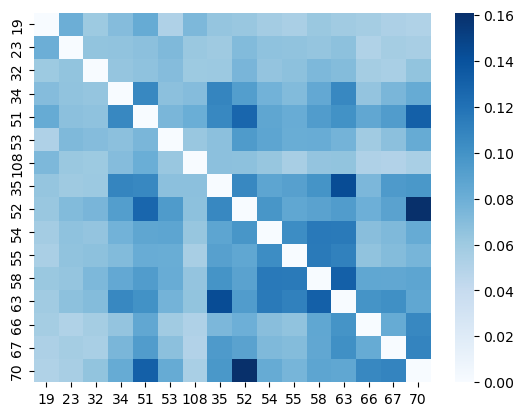

In [32]:
g=sns.heatmap(bp_net_comm_pre,
              cmap="Blues")
g.set_xticks([i+0.5 for i in range(len(pock))],
            pock)
g.set_yticks([i+0.5 for i in range(len(pock))],
            pock)
plt.show()

In [35]:
mtm_net_comm_pre=np.zeros((len(MTM_core),len(MTM_core)))
for i in MTM_core:
    for j in MTM_core:
        i_ind=MTM_core.index(i)
        j_ind=MTM_core.index(j)
        mtm_net_comm_pre[i_ind][j_ind]=WT_PRE_full_df[i-1][j-1]

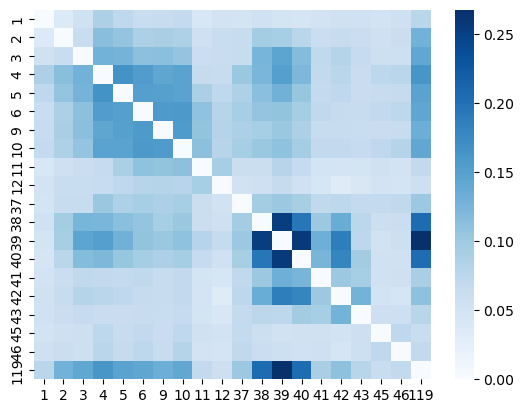

In [37]:
g=sns.heatmap(mtm_net_comm_pre,
              cmap="Blues")
g.set_xticks([i+0.5 for i in range(len(MTM_core))],
            MTM_core)
g.set_yticks([i+0.5 for i in range(len(MTM_core))],
            MTM_core)
plt.show()

In [104]:
overall_pre=[]
for comb_ in rSubset([i for i in range(1,120)], 2):
    overall_pre.append(WT_PRE_full_df[comb_[0]-1][comb_[1]-1])
    

In [105]:
bp_all_pre=[]
for i in triad_res:
    for j in range(1,120):
        if j not in triad_res:
            bp_all_pre.append(WT_PRE_full_df[i-1][j-1])

In [106]:
weight_pre=len(bp_all_pre)/len(overall_pre)
weight_pre

0.39652471157954705

In [107]:
(np.mean(bp_all_pre)/np.mean(overall_pre))*weight_pre

0.43307543830833817

In [90]:
0.1945+0.25605+0.433075+0.3990


1.282625

In [91]:
def group_contribution_seg_all(df_name, segment_name):
    overall_sys=[]
    for comb_ in rSubset([i for i in range(1,120)], 2):
        overall_sys.append(df_name[comb_[0]-1][comb_[1]-1])
    
    
    seg_all=[]
    for i in segment_name:
        for j in range(1,120):
            if j not in others:
                seg_all.append(df_name[i-1][j-1])
                
    
    weight_=len(seg_all)/len(overall_sys)
    
    contribution_=(np.mean(seg_all)/np.mean(overall_sys))*weight_
    
    return contribution_


In [94]:
group_contribution_seg_all(WT_PRE_full_df, triad_res)

0.5197484496720239

In [6]:
#UNB

WT_UNB_NC=pd.read_csv('../../../data/dihedrals/net_communication/LC3B_II_ER_protein/NET_COMM/LC3B_II_ER_protein_net_comm.csv',
                    index_col=0)
WT_UNB_full_np=WT_UNB_NC.to_numpy()+WT_UNB_NC.transpose().to_numpy()
WT_UNB_full_np=WT_UNB_full_np/np.max(WT_UNB_full_np)
WT_UNB_full_df=pd.DataFrame(WT_UNB_full_np)
WT_UNB_full_df

,0,1,2,3,4,5,6,7,8,9,...,109,110,111,112,113,114,115,116,117,118
0,0.000000,0.252592,0.236815,0.243170,0.194645,0.137060,0.109878,0.103053,0.137060,0.132555,...,0.072376,0.084087,0.099944,0.123600,0.158976,0.144991,0.202793,0.172997,0.212545,0.116410
1,0.252592,0.000000,0.331883,0.371719,0.327705,0.239599,0.170917,0.151606,0.239599,0.230593,...,0.076259,0.102260,0.137554,0.172455,0.245411,0.230283,0.382987,0.307054,0.408454,0.168614
2,0.236815,0.331883,0.000000,0.485563,0.494991,0.372946,0.271516,0.242909,0.372946,0.357831,...,0.090165,0.131910,0.211004,0.225733,0.272285,0.264781,0.343412,0.275390,0.349530,0.161337
3,0.243170,0.371719,0.485563,0.000000,0.612863,0.460740,0.333997,0.298732,0.460740,0.441635,...,0.101943,0.148564,0.242435,0.270025,0.333912,0.330500,0.426936,0.326236,0.425929,0.187439
4,0.194645,0.327705,0.494991,0.612863,0.000000,0.413453,0.323764,0.313370,0.413453,0.428419,...,0.118854,0.150255,0.247224,0.258760,0.321910,0.306356,0.331584,0.257482,0.313988,0.158640
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114,0.144991,0.230283,0.264781,0.330500,0.306356,0.197130,0.160809,0.160752,0.197130,0.194627,...,0.093097,0.165326,0.278677,0.275857,0.316883,0.000000,0.272667,0.232627,0.244741,0.156928
115,0.202793,0.382987,0.343412,0.426936,0.331584,0.183662,0.148995,0.145026,0.183662,0.181840,...,0.084006,0.134734,0.212131,0.226191,0.284492,0.272667,0.000000,0.274448,0.288977,0.193646
116,0.172997,0.307054,0.275390,0.326236,0.257482,0.149610,0.118211,0.115851,0.149610,0.137047,...,0.082830,0.117481,0.177624,0.178724,0.253477,0.232627,0.274448,0.000000,0.256976,0.180185
117,0.212545,0.408454,0.349530,0.425929,0.313988,0.172583,0.129076,0.128783,0.172583,0.160281,...,0.087614,0.106858,0.146539,0.169073,0.257896,0.244741,0.288977,0.256976,0.000000,0.178945


In [7]:
bp_net_comm_unb=np.zeros((len(pock),len(pock)))
for i in pock:
    for j in pock:
        i_ind=pock.index(i)
        j_ind=pock.index(j)
        bp_net_comm_unb[i_ind][j_ind]=WT_UNB_full_df[i-1][j-1]
        

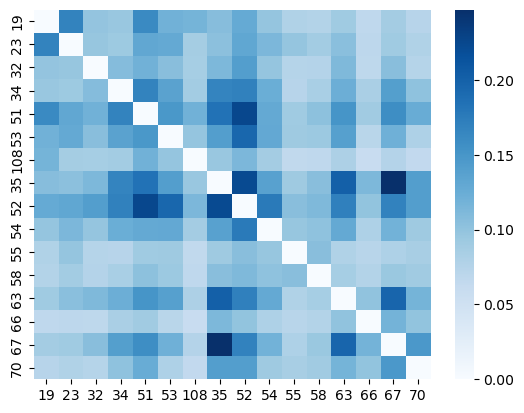

In [30]:
g=sns.heatmap(bp_net_comm_unb,
              cmap="Blues")
g.set_xticks([i+0.5 for i in range(len(pock))],
            pock)
g.set_yticks([i+0.5 for i in range(len(pock))],
            pock)
plt.show()

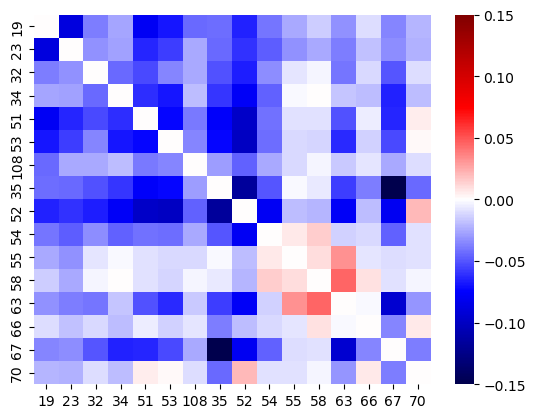

In [33]:
g=sns.heatmap(bp_net_comm_pre-bp_net_comm_unb,
           cmap="seismic",center=0, vmin=-0.15,vmax=0.15)
g.set_xticks([i+0.5 for i in range(len(pock))],
            pock)
g.set_yticks([i+0.5 for i in range(len(pock))],
            pock)


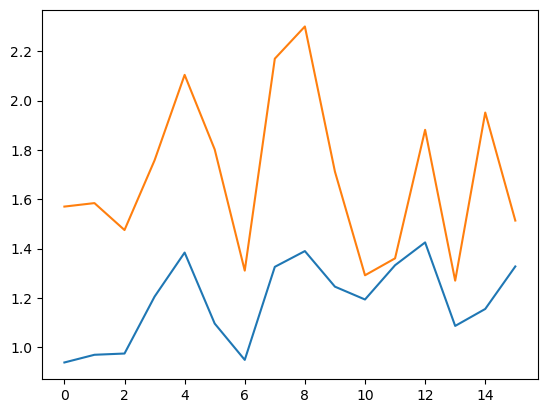

In [21]:
plt.plot(pd.DataFrame(bp_net_comm_pre).sum())
plt.plot(pd.DataFrame(bp_net_comm_unb).sum())
# ax.set

In [38]:
mtm_net_comm_unb=np.zeros((len(MTM_core),len(MTM_core)))
for i in MTM_core:
    for j in MTM_core:
        i_ind=MTM_core.index(i)
        j_ind=MTM_core.index(j)
        mtm_net_comm_unb[i_ind][j_ind]=WT_UNB_full_df[i-1][j-1]

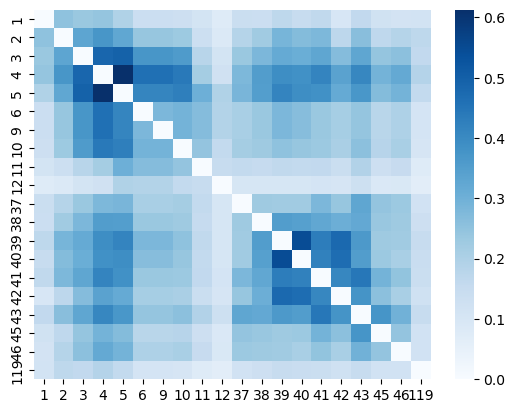

In [122]:
g=sns.heatmap(mtm_net_comm_unb,
              cmap="Blues")
g.set_xticks([i+0.5 for i in range(len(MTM_core))],
            MTM_core)
g.set_yticks([i+0.5 for i in range(len(MTM_core))],
            MTM_core)
plt.savefig("/Users/jesucastin/Desktop/MI_schematic.png", dpi=450,transparent=True )
        

/var/folders/pp/z1pgcq157pjgg48m2cg7wwkh0000gn/T/ipykernel_77204/2237784731.py:31: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar=plt.colorbar(f2rgb2, ticks=tk,shrink=0.3)


[Text(1, 0.0, '0.00'), Text(1, 0.12, '0.12'), Text(1, 0.25, '0.25')]

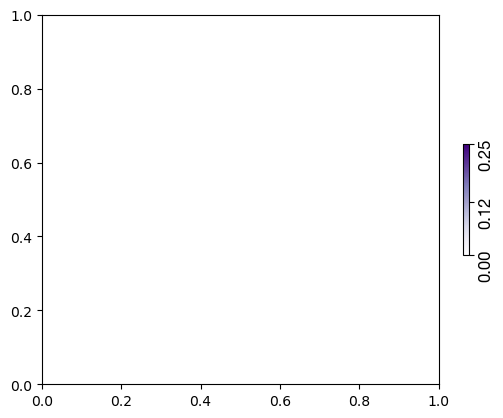

In [42]:

font = {'family':'helvetica neue',
        'color':  'black',
        'weight': 'bold',
        'size': 12
        }
rs={'family':'helvetica neue',
    'size':14
   }

import matplotlib.cm as cm
import matplotlib.colors as colors
mini=0
maxi=0.25
norm = colors.Normalize(vmin=mini, vmax=maxi)
# col_ls=['#845EC2','#D65DB1','#FF6F91','#FF9671','#FFC75F','#F9F871']
# col_ls=['#7B5360','#866E84',"#8E8BA1",'#9BA7B7','#B2C1C9','#D0DBDC','#ffffff']
# col_ls=['#EFEBE9','#D7CCC8','#BCAAA4','#A1887F','#8D6E63','#795548',
#        '#6D4C41','#5D4037','#4E342E','#392924']
# col_ls.reverse()

#cmp= colors.LinearSegmentedColormap.from_list("", col_ls)

# cm1=sns.color_palette("YlOrBr", as_cmap=True)

# cmp= colors.LinearSegmentedColormap.from_list("", ["#FEF9E7","#F7DC6F","#F1C40F","#B7950B"])

f2rgb2 = cm.ScalarMappable(norm=norm, cmap="Purples")
f2rgb2.set_array([])
tk=np.linspace(mini, maxi, 3)
tk=np.round(tk,2)
cbar=plt.colorbar(f2rgb2, ticks=tk,shrink=0.3)
cbar.ax.set_yticklabels(cbar.ax.get_yticklabels(), rotation=90,fontdict=font)


# plt.savefig('MEM_occup_cbar_.png',
#                    dpi=450,transparent=True,
#                    bbox_inches='tight')

In [44]:
def rSubset(arr, r):
    return list(combinations(arr, r))


# arr = LC3_resid

In [55]:
min(pd.DataFrame(bp_net_comm_pre).sum())

0.9384882445864512

In [56]:
max(pd.DataFrame(bp_net_comm_unb).sum())

2.300562062219737

In [57]:
min_size = 0.2  # Minimum size for the smallest value
max_size = 0.8  # Maximum size for the largest value

min_val=0.93
max_val=2.3

sizes=pd.DataFrame(bp_net_comm_unb).sum()

scaled_sizes = [(size - min_val) / (max_val - min_val) * (max_size - min_size) + min_size for size in sizes]



In [62]:
with open("unb_bp_net_comm_map.pml", "w+") as f_t:
    for c_ in rSubset(pock, 2):
        val_=WT_UNB_full_df[c_[0]-1][c_[1]-1]
        
        source_=c_[0]
        sink_=c_[1]
        
        f_t.write('show spheres, resi %d and name CA\n'%source_)
        f_t.write('show spheres, resi %d and name CA\n'%sink_)
        
        if val_>0.1:
            col=f2rgb2.to_rgba(val_)[:3]
            f_t.write('distance e_%d_%d,  resi %d and name CA, resi %d and name CA\n'%(source_,sink_,source_,sink_))
            #f_t.write('set dash_radius, 0.5, e_%d_%d\n'%(source_,sink_))

            f_t.write('set_color col_pal_e_%d_%d,[%0.4f,%0.4f,%0.4f]\n'%(source_,sink_,col[0],col[1],col[2]))
            f_t.write('set dash_color, col_pal_e_%d_%d, e_%d_%d\n'%(source_,sink_,source_,sink_))
f_t.close()

In [60]:
with open ("unb_bp_internal_stren.pml","w+") as f_sc:
    for i,j in zip(pock, scaled_sizes):
        f_sc.write("set sphere_scale, %f, resid %d and name CA\n"%(j,i))
f_sc.close()

0.125

In [66]:
with open("pre_bp_net_comm_map.pml", "w+") as f_t:
    for c_ in rSubset(pock, 2):
        val_=WT_PRE_full_df[c_[0]-1][c_[1]-1]
        
        source_=c_[0]
        sink_=c_[1]
        
        f_t.write('show spheres, resi %d and name CA\n'%source_)
        f_t.write('show spheres, resi %d and name CA\n'%sink_)
        
        if val_>0.05:
            col=f2rgb2.to_rgba(val_)[:3]
            f_t.write('distance e_%d_%d,  resi %d and name CA, resi %d and name CA\n'%(source_,sink_,source_,sink_))
            #f_t.write('set dash_radius, 0.5, e_%d_%d\n'%(source_,sink_))

            f_t.write('set_color col_pal_e_%d_%d,[%0.4f,%0.4f,%0.4f]\n'%(source_,sink_,col[0],col[1],col[2]))
            f_t.write('set dash_color, col_pal_e_%d_%d, e_%d_%d\n'%(source_,sink_,source_,sink_))
f_t.close()

In [64]:
min_size = 0.2  # Minimum size for the smallest value
max_size = 0.8  # Maximum size for the largest value

min_val=0.93
max_val=2.3

sizes=pd.DataFrame(bp_net_comm_pre).sum()

scaled_sizes = [(size - min_val) / (max_val - min_val) * (max_size - min_size) + min_size for size in sizes]



In [65]:
with open ("pre_bp_internal_stren.pml","w+") as f_sc:
    for i,j in zip(pock, scaled_sizes):
        f_sc.write("set sphere_scale, %f, resid %d and name CA\n"%(j,i))
f_sc.close()

In [103]:
group_contribution_seg_all(WT_UNB_full_df, MTM_core)

0.31573129321974125

In [110]:
min(pd.DataFrame(mtm_net_comm_pre).sum()),max(pd.DataFrame(mtm_net_comm_unb).sum())


(1.0804277057262326, 6.789896924849783)

In [113]:
np.min(mtm_net_comm_pre), np.max(mtm_net_comm_unb)

(0.0, 0.6128634365952407)

In [121]:
np.min(mtm_net_comm_pre),np.max(mtm_net_comm_pre)

(0.0, 0.26741745126671196)

/var/folders/pp/z1pgcq157pjgg48m2cg7wwkh0000gn/T/ipykernel_77204/2940812648.py:31: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar=plt.colorbar(f2rgb2, ticks=tk,shrink=0.3)


[Text(1, 0.0, '0.00'), Text(1, 0.31, '0.31'), Text(1, 0.62, '0.62')]

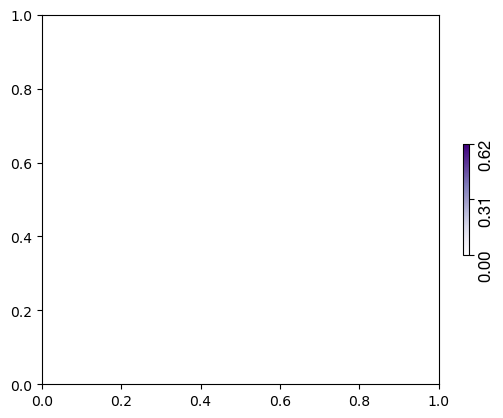

In [114]:

font = {'family':'helvetica neue',
        'color':  'black',
        'weight': 'bold',
        'size': 12
        }
rs={'family':'helvetica neue',
    'size':14
   }

import matplotlib.cm as cm
import matplotlib.colors as colors
mini=0
maxi=0.62
norm = colors.Normalize(vmin=mini, vmax=maxi)
# col_ls=['#845EC2','#D65DB1','#FF6F91','#FF9671','#FFC75F','#F9F871']
# col_ls=['#7B5360','#866E84',"#8E8BA1",'#9BA7B7','#B2C1C9','#D0DBDC','#ffffff']
# col_ls=['#EFEBE9','#D7CCC8','#BCAAA4','#A1887F','#8D6E63','#795548',
#        '#6D4C41','#5D4037','#4E342E','#392924']
# col_ls.reverse()

#cmp= colors.LinearSegmentedColormap.from_list("", col_ls)

# cm1=sns.color_palette("YlOrBr", as_cmap=True)

# cmp= colors.LinearSegmentedColormap.from_list("", ["#FEF9E7","#F7DC6F","#F1C40F","#B7950B"])

f2rgb2 = cm.ScalarMappable(norm=norm, cmap="Purples")
f2rgb2.set_array([])
tk=np.linspace(mini, maxi, 3)
tk=np.round(tk,2)
cbar=plt.colorbar(f2rgb2, ticks=tk,shrink=0.3)
cbar.ax.set_yticklabels(cbar.ax.get_yticklabels(), rotation=90,fontdict=font)


# plt.savefig('MEM_occup_cbar_.png',
#                    dpi=450,transparent=True,
#                    bbox_inches='tight')

In [115]:
with open("unb_mtm_net_comm_map.pml", "w+") as f_t:
    for c_ in rSubset(MTM_core, 2):
        val_=WT_UNB_full_df[c_[0]-1][c_[1]-1]
        
        source_=c_[0]
        sink_=c_[1]
        
        f_t.write('show spheres, resi %d and name CA\n'%source_)
        f_t.write('show spheres, resi %d and name CA\n'%sink_)
        
        if val_>0.1:
            col=f2rgb2.to_rgba(val_)[:3]
            f_t.write('distance e_%d_%d,  resi %d and name CA, resi %d and name CA\n'%(source_,sink_,source_,sink_))
            #f_t.write('set dash_radius, 0.5, e_%d_%d\n'%(source_,sink_))

            f_t.write('set_color col_pal_e_%d_%d,[%0.4f,%0.4f,%0.4f]\n'%(source_,sink_,col[0],col[1],col[2]))
            f_t.write('set dash_color, col_pal_e_%d_%d, e_%d_%d\n'%(source_,sink_,source_,sink_))
f_t.close()

In [116]:
min_size = 0.2  # Minimum size for the smallest value
max_size = 0.8  # Maximum size for the largest value

min_val=1.08
max_val=6.79

sizes=pd.DataFrame(mtm_net_comm_unb).sum()

scaled_sizes = [(size - min_val) / (max_val - min_val) * (max_size - min_size) + min_size for size in sizes]



In [117]:
with open ("unb_mtm_internal_stren.pml","w+") as f_sc:
    for i,j in zip(MTM_core, scaled_sizes):
        f_sc.write("set sphere_scale, %f, resid %d and name CA\n"%(j,i))
f_sc.close()

In [118]:
with open("pre_mtm_net_comm_map.pml", "w+") as f_t:
    for c_ in rSubset(MTM_core, 2):
        val_=WT_PRE_full_df[c_[0]-1][c_[1]-1]
        
        source_=c_[0]
        sink_=c_[1]
        
        f_t.write('show spheres, resi %d and name CA\n'%source_)
        f_t.write('show spheres, resi %d and name CA\n'%sink_)
        
        if val_>0.1:
            col=f2rgb2.to_rgba(val_)[:3]
            f_t.write('distance e_%d_%d,  resi %d and name CA, resi %d and name CA\n'%(source_,sink_,source_,sink_))
            #f_t.write('set dash_radius, 0.5, e_%d_%d\n'%(source_,sink_))

            f_t.write('set_color col_pal_e_%d_%d,[%0.4f,%0.4f,%0.4f]\n'%(source_,sink_,col[0],col[1],col[2]))
            f_t.write('set dash_color, col_pal_e_%d_%d, e_%d_%d\n'%(source_,sink_,source_,sink_))
f_t.close()

In [119]:
min_size = 0.2  # Minimum size for the smallest value
max_size = 0.8  # Maximum size for the largest value

min_val=1.08
max_val=6.79

sizes=pd.DataFrame(mtm_net_comm_pre).sum()

scaled_sizes = [(size - min_val) / (max_val - min_val) * (max_size - min_size) + min_size for size in sizes]



In [120]:
with open ("pre_mtm_internal_stren.pml","w+") as f_sc:
    for i,j in zip(MTM_core, scaled_sizes):
        f_sc.write("set sphere_scale, %f, resid %d and name CA\n"%(j,i))
f_sc.close()